<a href="https://colab.research.google.com/github/sesabe10/Ciencia-de-datos/blob/main/Copia_de_Laboratorio_T%C3%A9cnicas_Reducci%C3%B3nDimensionalidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio de Reducción de Dimensionalidad

Eres un científico de datos contratado por dos empresas con problemas críticos.

Tu misión es usar técnicas de reducción de dimensionalidad para ayudarlas a tomar decisiones estratégicas.


## MISIÓN 1: RETAIL – Evitar la fuga de clientes

La empresa ShopSmart quiere entender por qué los clientes abandonan.

Objetivo: Identificar variables importantes y reducir dimensionalidad.

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

data_retail = pd.DataFrame({
    'visitas_web_mes': np.random.randint(1, 50, 100),
    'uso_descuento': np.random.randint(0, 2, 100),
    'satisfaccion': np.random.randint(1, 10, 100),
    'compras_previas': np.random.randint(1, 20, 100),
    'ingreso_mensual': np.random.randint(500, 5000, 100),
    'abandono_cliente': np.random.randint(0, 2, 100)
})

data_retail.head()

,visitas_web_mes,uso_descuento,satisfaccion,compras_previas,ingreso_mensual,abandono_cliente
0,39,0,7,11,3624,1
1,29,1,9,17,3551,1
2,15,1,7,8,504,0
3,43,1,1,4,1376,0
4,8,0,1,6,1491,1


### Actividad: Correlación

Analiza qué variables están relacionadas con el abandono.

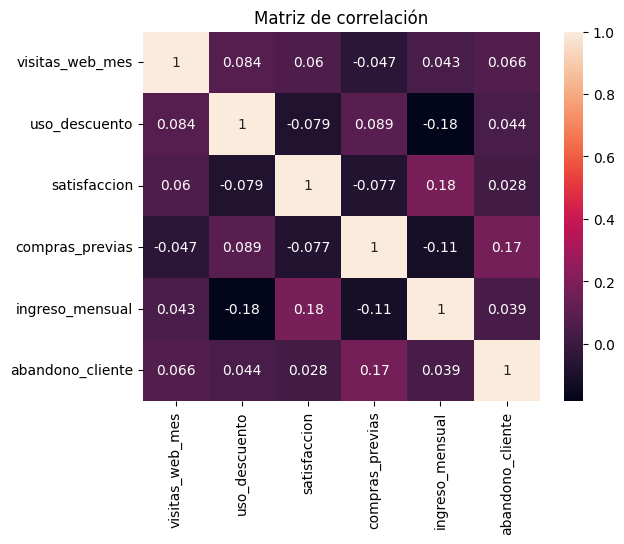

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = data_retail.corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title('Matriz de correlación')
plt.show()

**Preguntas:**
- ¿Qué variables se relacionan más con abandono_cliente?
  - **compras_previas**: es la que tiene la mayor correlación, pero 0.17 sigue siendo correlación débil no hay ninguna variable con una correlación fuerte > .50, esto podría indicar que el abandono no depende de uan sola variable.
- ¿Eliminarías alguna variable?
  - De momento no eliminaría nignuna variable, por si solas no aportan mucho pero en grupo s ele puede sacar provecho a la información.


### Actividad: Escalamiento

Aplica MinMax y Estandarización.

In [3]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd

features = ['visitas_web_mes','uso_descuento','satisfaccion','compras_previas','ingreso_mensual']

# Escalamiento MinMax
scaler_minmax = MinMaxScaler()
data_minmax = scaler_minmax.fit_transform(data_retail[features])

# Escalamiento Z-score
scaler_std = StandardScaler()
data_std = scaler_std.fit_transform(data_retail[features])

# Convertir a DataFrame para visualizar
df_minmax = pd.DataFrame(data_minmax, columns=features)
df_std = pd.DataFrame(data_std, columns=features)

print("Datos originales:")
display(data_retail[features].head())

print("\n Min-Max Scaling:")
display(df_minmax.head())

print("\n Z-score Scaling:")
display(df_std.head())

Datos originales:


,visitas_web_mes,uso_descuento,satisfaccion,compras_previas,ingreso_mensual
0,39,0,7,11,3624
1,29,1,9,17,3551
2,15,1,7,8,504
3,43,1,1,4,1376
4,8,0,1,6,1491



 Min-Max Scaling:


,visitas_web_mes,uso_descuento,satisfaccion,compras_previas,ingreso_mensual
0,0.791667,0.0,0.75,0.555556,0.699395
1,0.583333,1.0,1.00,0.888889,0.683031
2,0.291667,1.0,0.75,0.388889,0.000000
3,0.875000,1.0,0.00,0.166667,0.195472
4,0.145833,0.0,0.00,0.277778,0.221251



 Z-score Scaling:


,visitas_web_mes,uso_descuento,satisfaccion,compras_previas,ingreso_mensual
0,1.041901,-0.886405,0.777683,0.241120,0.666340
1,0.328270,1.128152,1.497760,1.245786,0.608562
2,-0.670813,1.128152,0.777683,-0.261213,-1.803051
3,1.327353,1.128152,-1.382548,-0.930990,-1.112888
4,-1.170354,-0.886405,-1.382548,-0.596102,-1.021869


**Preguntas:**
- ¿Qué diferencias observas?
  - Min-Max Scaling:

  - Resultado: Transforma los datos al rango [0, 1].

  - Ventaja: Permite comparar todo en igualdad de condiciones.

  - Desventaja: Muy sensible a valores atípicos (outliers), que pueden comprimir el resto de los datos.

  - Z-score Scaling (Estandarización):

    - Resultado: Centra los datos en una media de 0 y desviación estándar de 1.

    - Ventaja: Más robusto ante valores extremos y preferible para datos con distribución normal.

- ¿Cuál usarías para PCA?  
Usaría Z-score Scaling (estandarización).  

¿Por qué?  

PCA funciona calculando varianza y covarianza entre variables. Si las variables están en escalas distintas, las de mayor magnitud dominarán los componentes principales, no por ser más informativas, sino simplemente por tener números más grandes.
El Z-score garantiza que cada variable aporte con igual peso inicial, dejando que PCA detecte las direcciones de mayor varianza real en los datos.


### Actividad: PCA

Reduce dimensiones y analiza la varianza.

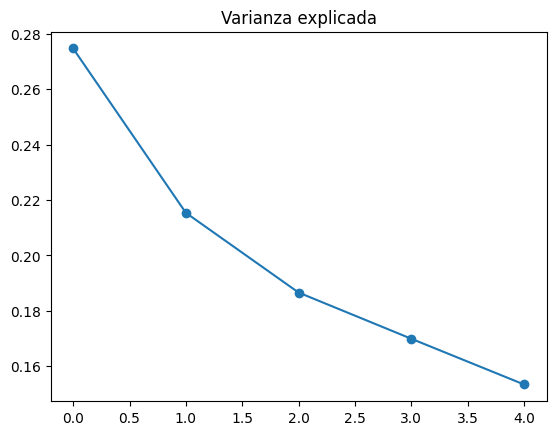

In [4]:
from sklearn.decomposition import PCA

pca = PCA() #Se crea un modelo de Análisis de Componentes Principales (PCA)
pca.fit(data_std) #Ajustar el modelo a los datos

explained_variance = pca.explained_variance_ratio_ #Obtener la varianza

plt.figure()
plt.plot(explained_variance, marker='o')
plt.title('Varianza explicada')
plt.show()

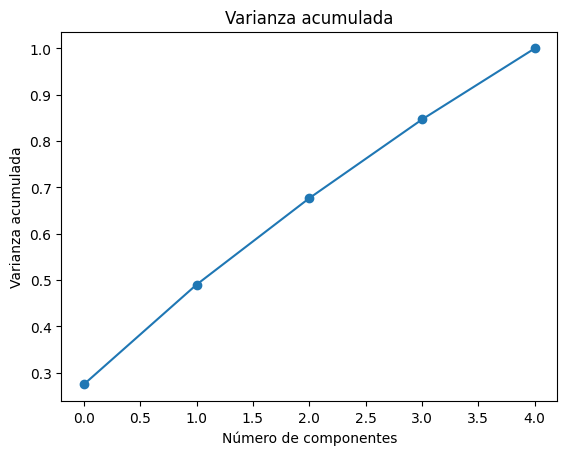

In [5]:
import numpy as np

var_acumulada = np.cumsum(explained_variance)

plt.plot(var_acumulada, marker='o')
plt.title('Varianza acumulada')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.show()

**Preguntas:**
- ¿Cuántos componentes usarías?
    - Si el objetivo es reducir dimensiones para un modelo de Machine Learning sin perder demasiada capacidad predictiva, yo elegiría 3 o 4 componentes.  
    - Usar 3 componentes si quieres una reducción real (pasar de 5 a 3 variables) manteniendo una representación decente (~68%).
- ¿Cómo lo explicarías a un gerente?
  - Estamos filtrando el ruido. Al quedarnos con 3 componentes, eliminamos los datos redundantes y nos enfocamos en el 70% de los factores que realmente mueven la aguja, permitiendo que el sistema tome decisiones más ágiles.


## MISIÓN 2: BANCA – Reducir riesgo financiero

El banco CreditSafe necesita mejorar sus decisiones de crédito.

**Objetivo**: Identificar variables clave.

In [6]:
from sklearn.preprocessing import LabelEncoder

data_banco = pd.DataFrame({
    'historial_credito': np.random.choice(['bueno','malo'], 100),
    'tipo_empleo': np.random.choice(['fijo','temporal'], 100),
    'aprobado': np.random.randint(0,2,100)
})

le = LabelEncoder() #Codificador convierte texto → números

data_banco['historial_credito'] = le.fit_transform(data_banco['historial_credito']) #Transforma variables categóricas (bueno = 1, malo = 0)
data_banco['tipo_empleo'] = le.fit_transform(data_banco['tipo_empleo'])

data_banco.head()

,historial_credito,tipo_empleo,aprobado
0,0,0,0
1,1,1,0
2,0,1,0
3,1,1,1
4,1,1,0


### Actividad: Chi-cuadrado

Evalúa qué variable es más importante.

In [7]:
from sklearn.feature_selection import chi2

X = data_banco[['historial_credito','tipo_empleo']]
y = data_banco['aprobado']

chi_scores = chi2(X, y)
chi_scores

(array([1.54153755, 1.00960384]), array([0.21438909, 0.31499777]))

### Actividad: Correlación de Pearson

Evalúa qué variable es más importante.

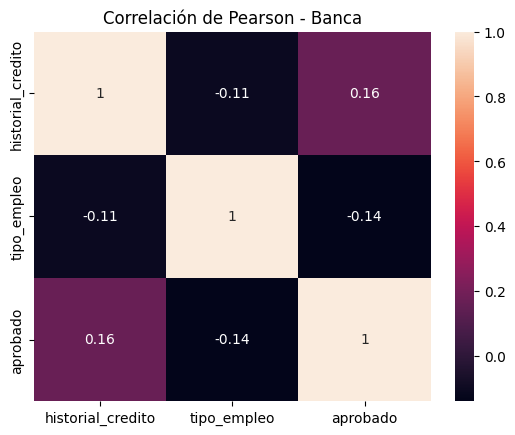

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_banco = data_banco.corr()

plt.figure()
sns.heatmap(corr_banco, annot=True)
plt.title("Correlación de Pearson - Banca")
plt.show()

**Preguntas:**
- ¿Qué variable es más relevante?
  - historial_credito es la variable más relevante para predecir aprobado, con una correlación de +0.16, frente a tipo_empleo que muestra -0.14.
- ¿Cómo ayuda esto al banco?
  - El banco puede usar estas variables para:

    - Priorizar el historial crediticio como primer filtro de evaluación
    - Considerar el tipo de empleo como factor secundario de riesgo
    - Combinar ambas en un modelo de scoring, ya que no están correlacionadas entre sí (evita multicolinealidad)


## MISIÓN FINAL

Completa la siguiente tabla:

| Caso | Técnica recomendada | Justificación |
|------|-------------------|--------------|
| Retail | PCA + Min-Max Scaling| Las variables de comportamiento del cliente (visitas, compras, ingresos) tienen escalas muy distintas. Min-Max normaliza al rango [0,1] y PCA reduce la dimensionalidad preservando los patrones de consumo. Esto permite segmentar clientes y personalizar ofertas de forma eficiente.|
| Banca | Correlación de Pearson + Z-score Scaling| Con variables como historial crediticio y tipo de empleo, es clave entender qué factores influyen en la aprobación. Z-score estandariza correctamente variables financieras y la correlación identifica las más relevantes para el modelo de riesgo crediticio.|

Explica cómo tus decisiones ayudan al negocio (máx. 5 líneas por caso).
